# TASK 04 &nbsp;|&nbsp; Baseline CNN - ResNet-18 on LIDC-IDRI



## 4.0 &nbsp;Configuration


In [1]:
import os, sys, json, math, time, random, warnings, glob, zipfile, shutil, hashlib
from pathlib import Path
warnings.filterwarnings("ignore")

CFG = dict(
    SEED = 42,

    # ---------- WHICH MODEL THIS NOTEBOOK TRAINS ----------
    MODEL         = "resnet18",
    PRETRAINED    = True,

    # ---------- data source ----------
    DATA_SOURCE   = "auto",        # auto | cache | lidc_raw | phantom
    CACHE_NAME    = "lidc_nodules_cache.npz",
    WORK          = "/kaggle/working",
    RAW_DIR       = "/kaggle/temp/lidc_raw",     # /kaggle/temp is not size-capped like /working
    XML_DIR       = "/kaggle/temp/lidc_xml",

    # ---------- LIDC nodule extraction ----------
    # Every value below is part of the PROTOCOL and is hashed into the dataset fingerprint.
    # Task 4 and Task 5 must agree on all of them or their results are not comparable.
    N_PATIENTS    = 300,           # 300 patients ~ 700-900 usable nodules
    MIN_READERS   = 3,             # nodule must be marked by >= this many of the 4 radiologists
    DROP_SCORE_3  = True,          # median malignancy == 3 -> ambiguous -> excluded (standard)
    MATCH_MM      = 6.0,           # cross-reader nodule matching radius
    PATCH_MM      = 48.0,          # crop is 48mm x 48mm of real anatomy, resampled to IMG_SIZE
    IMG_SIZE      = 224,
    N_SLICES      = 3,             # 1 = single axial slice, 3 = 2.5D (3 adjacent slices -> RGB)
    HU_WINDOW     = (-1000.0, 400.0),

    # ---------- patient-level cross-validation ----------
    N_FOLDS            = 5,        # Task 4 spec: patient-level 5-fold CV
    VAL_FRAC_OF_TRAIN  = 0.15,     # carved out of each fold's training pool, for early stopping

    # ---------- training ----------
    EPOCHS        = 30,
    BATCH_SIZE    = 32,
    LR            = 3e-4,
    WEIGHT_DECAY  = 1e-4,
    DROPOUT_P     = 0.30,          # TASK 6 needs this > 0 at train time
    DROPOUT_MODE  = "head_and_stages",   # head | head_and_stages
    PATIENCE      = 7,
    AMP           = True,
    NUM_WORKERS   = 2,
    CLASS_WEIGHTS = True,

    # ---------- evaluation ----------
    TARGET_SPECIFICITIES = [0.90, 0.95, 0.99],
    N_BOOTSTRAP   = 1000,
    N_ECE_BINS    = 15,

    # ---------- TASK 6 : MC dropout ----------
    MC_PASSES     = 50,
    UQ_TARGET_SENSITIVITY = 0.98,
)

CFG["OUT_DIR"]    = f"{CFG['WORK']}/{CFG['MODEL']}_task_outputs"
CFG["CACHE_PATH"] = f"{CFG['WORK']}/{CFG['CACHE_NAME']}"
Path(CFG["OUT_DIR"]).mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["benign", "malignant"]
IS_SMOKE = False          # flipped True by the phantom fallback; gates all reporting

# Keys that define the protocol. Both notebooks must match on these, so they are hashed into
# the fingerprint that ships with the results bundle.
PROTOCOL_KEYS = ["SEED", "N_PATIENTS", "MIN_READERS", "DROP_SCORE_3", "MATCH_MM", "PATCH_MM",
                 "IMG_SIZE", "N_SLICES", "HU_WINDOW", "N_FOLDS", "VAL_FRAC_OF_TRAIN"]

print(f"This notebook trains: {CFG['MODEL']}")
print(json.dumps(CFG, indent=2, default=str))

This notebook trains: resnet18
{
  "SEED": 42,
  "MODEL": "resnet18",
  "PRETRAINED": true,
  "DATA_SOURCE": "auto",
  "CACHE_NAME": "lidc_nodules_cache.npz",
  "WORK": "/kaggle/working",
  "RAW_DIR": "/kaggle/temp/lidc_raw",
  "XML_DIR": "/kaggle/temp/lidc_xml",
  "N_PATIENTS": 300,
  "MIN_READERS": 3,
  "DROP_SCORE_3": true,
  "MATCH_MM": 6.0,
  "PATCH_MM": 48.0,
  "IMG_SIZE": 224,
  "N_SLICES": 3,
  "HU_WINDOW": [
    -1000.0,
    400.0
  ],
  "N_FOLDS": 5,
  "VAL_FRAC_OF_TRAIN": 0.15,
  "EPOCHS": 30,
  "BATCH_SIZE": 32,
  "LR": 0.0003,
  "WEIGHT_DECAY": 0.0001,
  "DROPOUT_P": 0.3,
  "DROPOUT_MODE": "head_and_stages",
  "PATIENCE": 7,
  "AMP": true,
  "NUM_WORKERS": 2,
  "CLASS_WEIGHTS": true,
  "TARGET_SPECIFICITIES": [
    0.9,
    0.95,
    0.99
  ],
  "N_BOOTSTRAP": 1000,
  "N_ECE_BINS": 15,
  "MC_PASSES": 50,
  "UQ_TARGET_SENSITIVITY": 0.98,
  "OUT_DIR": "/kaggle/working/resnet18_task_outputs",
  "CACHE_PATH": "/kaggle/working/lidc_nodules_cache.npz"
}


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False   # keep benchmark speed; seeds still control init/sampling
    torch.backends.cudnn.benchmark = True

set_seed(CFG["SEED"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

# timm supplies the ViT for Task 5. Preinstalled on recent Kaggle images.
try:
    import timm
    print("timm", timm.__version__)
except ImportError:
    get_ipython().system("pip install -q timm")
    import timm
    print("timm", timm.__version__, "(freshly installed)")


def gpu_preflight():
    """Prove the GPU can actually run a convolution BEFORE anything expensive happens.

    A PyTorch wheel only ships kernels for the GPU architectures it was compiled for. If the
    attached accelerator is older than anything in that list, every CUDA op raises
    "no kernel image is available for execution on the device" - but only when it is first
    called, which is inside the training loop, which here is after a multi-hour download.
    One tiny convolution at setup time turns a wasted session into a two-second error.
    """
    if not torch.cuda.is_available():
        print("")
        print("!! No GPU visible. Five folds at 224x224 on CPU is not practical.")
        print("   Kaggle sidebar -> Session options -> Accelerator -> GPU T4 x2")
        return False

    name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    mine = f"sm_{major}{minor}"
    built_for = [a for a in torch.cuda.get_arch_list() if a.startswith("sm_")]
    print("")
    print(f"GPU               : {name}")
    print(f"compute capability: {mine}")
    print(f"torch built for   : {', '.join(built_for) or 'unknown'}")

    try:
        x = torch.zeros(1, 3, 8, 8, device="cuda")
        w = torch.zeros(4, 3, 3, 3, device="cuda")
        torch.nn.functional.conv2d(x, w)
        torch.cuda.synchronize()
        print("preflight         : OK - a real convolution ran on the device")
        print("")
        return True
    except Exception as e:
        raise RuntimeError(f"""
==========================================================================
THIS GPU CANNOT RUN THIS PYTORCH BUILD - stopping before the download.
==========================================================================
  GPU                 : {name}  ({mine})
  torch {torch.__version__}
  has kernels for     : {', '.join(built_for)}
  underlying error    : {type(e).__name__}: {e}

  {mine} is not in that list, so every CUDA operation on this device fails.

  FIX: Kaggle sidebar -> Session options -> Accelerator -> "GPU T4 x2",
       then Run All again. The T4 is sm_75 and is covered by this build.

  (A P100 is sm_60 - Pascal - which recent CUDA 12.x wheels no longer ship
   kernels for. The arch list printed above is the authoritative answer for
   whatever GPU you were given.)
==========================================================================
""") from e


GPU_OK = gpu_preflight()

torch 2.10.0+cpu | device: cpu | no GPU
timm 1.0.26

!! No GPU visible. Five folds at 224x224 on CPU is not practical.
   Kaggle sidebar -> Session options -> Accelerator -> GPU T4 x2


## 4.1 &nbsp;Data layer - building labelled nodules from LIDC-IDRI

### 4.1.1 &nbsp;Why this section exists

The LIDC-IDRI label is not a column in a CSV. It is produced by up to four radiologists who each
independently outlined every nodule they saw and scored it on nine characteristics, malignancy
being one of them (1 = highly unlikely, 5 = highly suspicious). Turning that into a training label
requires three decisions, and every LIDC paper makes them - the numbers are only comparable
between papers that made them the same way. Ours, matching the dominant convention:

| Decision | Choice | Why |
|---|---|---|
| Which nodules to keep | marked by `MIN_READERS` = 3+ radiologists | 1-reader nodules are noisy and inflate scores |
| How to fuse the 4 ratings | **median** | robust to one dissenting reader; standard in the literature |
| What to do with median == 3 | **drop** | "indeterminate" is neither benign nor malignant; keeping it corrupts both classes |

These are recorded in `CFG` so the exact protocol is reproducible and quotable in the paper.
The other eight characteristics (spiculation, margin, subtlety, lobulation, calcification,
texture, sphericity, internal structure) are cached too - Task 8's concept-based explainability
(TCAV/ACE) needs them, and re-extracting later would mean re-downloading everything.

In [4]:
import xml.etree.ElementTree as ET
from collections import defaultdict

def _tag(elem):
    """LIDC XMLs carry a namespace that varies between files. Compare on the local name only."""
    return elem.tag.split("}")[-1]

CHARACTERISTIC_KEYS = ["subtlety", "internalStructure", "calcification", "sphericity",
                       "margin", "lobulation", "spiculation", "texture", "malignancy"]

def parse_lidc_xml(xml_path):
    """One LIDC XML -> (series_uid, [reading_session, ...]).

    Each reading_session is one radiologist's list of nodules; each nodule carries its
    characteristic scores and its per-slice contours. Nodules with no <characteristics>
    block are the <3mm marks, which have no malignancy rating - dropped here.
    """
    root = ET.parse(xml_path).getroot()

    series_uid = None
    for e in root.iter():
        if _tag(e) in ("SeriesInstanceUid", "SeriesInstanceUID"):
            series_uid = (e.text or "").strip()
            break

    sessions = []
    for sess in root.iter():
        if _tag(sess) != "readingSession":
            continue
        nodules = []
        for nod in sess:
            if _tag(nod) != "unblindedReadNodule":
                continue
            nid, chars, rois = None, {}, []
            for child in nod:
                t = _tag(child)
                if t == "noduleID":
                    nid = (child.text or "").strip()
                elif t == "characteristics":
                    for c in child:
                        try:
                            chars[_tag(c)] = int(float((c.text or "").strip()))
                        except (TypeError, ValueError):
                            pass
                elif t == "roi":
                    z, sop, pts, included = None, None, [], True
                    for r in child:
                        rt = _tag(r)
                        if rt == "imageZposition":
                            z = float(r.text)
                        elif rt == "imageSOP_UID":
                            sop = (r.text or "").strip()
                        elif rt == "inclusion":
                            included = (r.text or "").strip().upper() == "TRUE"
                        elif rt == "edgeMap":
                            x = y = None
                            for e2 in r:
                                if _tag(e2) == "xCoord":   x = int(float(e2.text))
                                elif _tag(e2) == "yCoord": y = int(float(e2.text))
                            if x is not None and y is not None:
                                pts.append((x, y))
                    if pts and included:
                        rois.append(dict(z=z, sop=sop, pts=np.asarray(pts, dtype=np.float32)))
            # no malignancy score -> unusable as a label, however good the contour
            if rois and "malignancy" in chars:
                nodules.append(dict(nodule_id=nid, characteristics=chars, rois=rois))
        sessions.append(nodules)

    return series_uid, sessions


def nodule_geometry(nodule):
    """Centroid as (col, row, z_mm) plus the largest in-plane diameter, in pixels."""
    all_pts = np.concatenate([r["pts"] for r in nodule["rois"]], axis=0)
    cx, cy = all_pts[:, 0].mean(), all_pts[:, 1].mean()
    zs = [r["z"] for r in nodule["rois"] if r["z"] is not None]
    cz = float(np.mean(zs)) if zs else None
    diam_px = 0.0
    for r in nodule["rois"]:
        p = r["pts"]
        if len(p) > 1:
            diam_px = max(diam_px, float(np.hypot(np.ptp(p[:, 0]), np.ptp(p[:, 1]))))
    return float(cx), float(cy), cz, diam_px

### 4.1.2 &nbsp;Matching the same nodule across radiologists

The four readers worked blind to each other, so reader 1's "nodule 3" and reader 4's "nodule 1" may
be the same lesion. They must be grouped before the ratings can be fused. Grouping is by spatial
proximity of centroids in millimetres, with one constraint a naive nearest-neighbour pass would get
wrong: **a cluster may contain at most one nodule per reader.** Without it, two genuinely distinct
lesions that a single reader marked close together collapse into one cluster and its reader count
becomes meaningless - which then silently breaks the `MIN_READERS` filter.

In [5]:
def cluster_nodules_across_readers(sessions, spacing_xy, match_mm):
    """Group per-reader nodule marks into physical lesions.

    Greedy agglomeration on centroid distance in mm, with the one-nodule-per-reader constraint.
    Returns a list of clusters; each cluster is a list of per-reader mark records.
    """
    items = []
    for r_idx, nodules in enumerate(sessions):
        for nod in nodules:
            cx, cy, cz, diam = nodule_geometry(nod)
            if cz is None:
                continue
            items.append(dict(reader=r_idx, nodule=nod, cx=cx, cy=cy, cz=cz, diam_px=diam))

    # Deterministic order so the same input always yields the same clusters.
    items.sort(key=lambda d: (d["cz"], d["cx"], d["cy"], d["reader"]))
    sx, sy = spacing_xy
    clusters = []

    for it in items:
        best, best_d = None, np.inf
        for cl in clusters:
            if any(m["reader"] == it["reader"] for m in cl):
                continue                                   # this reader is already represented
            mcx = np.mean([m["cx"] for m in cl]); mcy = np.mean([m["cy"] for m in cl])
            mcz = np.mean([m["cz"] for m in cl])
            d = math.sqrt(((it["cx"] - mcx) * sx) ** 2 +
                          ((it["cy"] - mcy) * sy) ** 2 +
                          (it["cz"] - mcz) ** 2)
            if d < best_d:
                best, best_d = cl, d
        if best is not None and best_d <= match_mm:
            best.append(it)
        else:
            clusters.append([it])
    return clusters


def fuse_cluster_labels(cluster, min_readers, drop_score_3):
    """Cluster of per-reader marks -> one labelled nodule, or None if it fails the protocol."""
    readers = sorted({m["reader"] for m in cluster})
    if len(readers) < min_readers:
        return None

    scores = defaultdict(list)
    for m in cluster:
        for k in CHARACTERISTIC_KEYS:
            if k in m["nodule"]["characteristics"]:
                scores[k].append(m["nodule"]["characteristics"][k])
    if not scores.get("malignancy"):
        return None

    mal_median = float(np.median(scores["malignancy"]))
    if drop_score_3 and abs(mal_median - 3.0) < 1e-9:
        return None
    label = int(mal_median > 3.0)

    return dict(
        n_readers   = len(readers),
        malignancy  = mal_median,
        label       = label,
        # Disagreement between readers. Task 6 uses this as a reference for irreducible
        # (aleatoric) label noise: cases the radiologists split on are cases the model
        # should be uncertain about too.
        mal_std     = float(np.std(scores["malignancy"])),
        mal_ratings = ",".join(str(int(v)) for v in scores["malignancy"]),
        cx = float(np.mean([m["cx"] for m in cluster])),
        cy = float(np.mean([m["cy"] for m in cluster])),
        cz = float(np.mean([m["cz"] for m in cluster])),
        diam_px = float(np.mean([m["diam_px"] for m in cluster])),
        **{f"c_{k}": float(np.median(v)) for k, v in scores.items()},
    )

### 4.1.3 &nbsp;Reading the CT series and cutting patches

Two details that matter more than they look:

**Patches are sized in millimetres, not pixels.** Pixel spacing across the 3 patients Task 3
already pulled ranges 0.664 - 0.781 mm. A fixed 64x64-pixel crop would therefore contain ~18% more
anatomy on one scan than another, and the network would be partly learning scanner settings. So we
crop `PATCH_MM` = 48 mm of real tissue and resample to `IMG_SIZE`, making nodule size physically
comparable across patients.

**`N_SLICES` = 3 gives a 2.5D input for free.** Three adjacent axial slices stacked as three
channels feed an ImageNet-pretrained 3-channel stem with no surgery, and carry some through-plane
context a single slice does not. Set it to 1 for a strict 2D baseline.

In [6]:
def load_ct_series(series_dir):
    """Read one DICOM CT series -> HU volume sorted along z, plus geometry."""
    import pydicom
    paths = glob.glob(os.path.join(series_dir, "**", "*.dcm"), recursive=True)
    slices = []
    for p in paths:
        try:
            ds = pydicom.dcmread(p, force=True)
            if not hasattr(ds, "PixelData") or not hasattr(ds, "ImagePositionPatient"):
                continue
            if getattr(ds, "Modality", "CT") != "CT":
                continue
            slices.append(ds)
        except Exception:
            continue
    if len(slices) < 10:
        return None

    slices.sort(key=lambda d: float(d.ImagePositionPatient[2]))
    ref = slices[0]
    slope     = float(getattr(ref, "RescaleSlope", 1.0))
    intercept = float(getattr(ref, "RescaleIntercept", 0.0))
    spacing   = [float(v) for v in getattr(ref, "PixelSpacing", [1.0, 1.0])]

    vol = np.stack([s.pixel_array.astype(np.float32) for s in slices], axis=0)
    vol = vol * slope + intercept                   # stored values -> Hounsfield Units
    vol[vol < -2000] = -1000.0                      # outside-the-bore padding -> air

    return dict(
        vol       = vol,                                              # (z, y, x) HU
        z_pos     = np.array([float(s.ImagePositionPatient[2]) for s in slices]),
        spacing   = (spacing[1], spacing[0]),                         # (x, y) mm per pixel
        thickness = float(getattr(ref, "SliceThickness", 1.0)),
        n_slices  = len(slices),
        patient_id= str(getattr(ref, "PatientID", "")),
        series_uid= str(getattr(ref, "SeriesInstanceUID", "")),
    )


def window_to_uint8(patch_hu, hu_window):
    lo, hi = hu_window
    x = (np.clip(patch_hu, lo, hi) - lo) / (hi - lo)
    return (x * 255.0).astype(np.uint8)


def extract_patch(series, nod, patch_mm, img_size, n_slices, hu_window):
    """Nodule centroid -> (n_slices, img_size, img_size) uint8 patch, or None."""
    import cv2
    vol, z_pos = series["vol"], series["z_pos"]
    sx, sy = series["spacing"]

    z_idx  = int(np.argmin(np.abs(z_pos - nod["cz"])))
    half_x = max(2, int(round((patch_mm / 2.0) / sx)))
    half_y = max(2, int(round((patch_mm / 2.0) / sy)))
    cx, cy = int(round(nod["cx"])), int(round(nod["cy"]))

    offsets = [0] if n_slices == 1 else list(range(-(n_slices // 2), n_slices // 2 + 1))
    out = []
    for off in offsets:
        zi = int(np.clip(z_idx + off, 0, vol.shape[0] - 1))
        # Pad first, so a nodule against the chest wall still yields a full-size CENTRED crop.
        # Cropping first and padding after would shift the nodule off-centre.
        pad_y, pad_x = half_y + 1, half_x + 1
        padded = np.pad(vol[zi], ((pad_y, pad_y), (pad_x, pad_x)),
                        mode="constant", constant_values=hu_window[0])
        py, px = cy + pad_y, cx + pad_x
        crop = padded[py - half_y: py + half_y, px - half_x: px + half_x]
        if crop.size == 0:
            return None
        out.append(cv2.resize(window_to_uint8(crop, hu_window), (img_size, img_size),
                              interpolation=cv2.INTER_LINEAR))
    return np.stack(out, axis=0)

### 4.1.4 &nbsp;Fetching raw LIDC-IDRI (DICOM **and** the XML annotations Task 3 was missing)

`tcia_utils` handles the images. The annotations are a separate ~50 MB package. If the URL has moved
(TCIA reorganises its downloads periodically), the cell fails with printed instructions instead of
silently continuing with no labels - which is exactly the failure mode that produced the empty
`no annotations found` result in Task 3.

In [7]:
def download_lidc_dicom(n_patients, out_dir):
    """Download one CT series per patient for the first n_patients (deterministic selection)."""
    try:
        from tcia_utils import nbia
    except ImportError:
        get_ipython().system("pip install -q tcia_utils")
        from tcia_utils import nbia

    os.makedirs(out_dir, exist_ok=True)
    df = pd.DataFrame(nbia.getSeries(collection="LIDC-IDRI"))
    df = df[df["Modality"] == "CT"].copy()               # LIDC also contains DX/CR radiographs
    df["ImageCount"] = pd.to_numeric(df["ImageCount"], errors="coerce").fillna(0)

    # One series per patient: the largest stack, i.e. the diagnostic CT rather than a scout.
    df = (df.sort_values(["PatientID", "ImageCount"], ascending=[True, False])
            .groupby("PatientID", as_index=False).first()
            .sort_values("PatientID"))
    sel = df.head(n_patients)
    print(f"LIDC-IDRI: {df.PatientID.nunique()} patients with CT | selecting {len(sel)}")
    print(f"Estimated download: ~{0.9 * sel.ImageCount.sum() / 1000:.1f} GB "
          f"({int(sel.ImageCount.sum())} slices)")

    nbia.downloadSeries(sel.to_dict("records"), path=out_dir)
    return sel


LIDC_XML_URLS = [
    "https://www.cancerimagingarchive.net/wp-content/uploads/LIDC-XML-only.zip",
    "https://wiki.cancerimagingarchive.net/download/attachments/1966254/LIDC-XML-only.zip",
]

def download_lidc_xml(xml_dir, urls=LIDC_XML_URLS):
    """Fetch + unzip the LIDC XML annotation package. Raises loudly if unavailable."""
    import requests
    os.makedirs(xml_dir, exist_ok=True)
    if glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True):
        print("XML annotations already present, skipping download.")
        return xml_dir

    zip_path = os.path.join(xml_dir, "LIDC-XML-only.zip")
    for url in urls:
        try:
            print("Trying", url)
            with requests.get(url, stream=True, timeout=180) as r:
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    for chunk in r.iter_content(1 << 20):
                        f.write(chunk)
            with zipfile.ZipFile(zip_path) as z:
                z.extractall(xml_dir)
            os.remove(zip_path)
            n = len(glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True))
            print(f"Extracted {n} annotation XMLs.")
            return xml_dir
        except Exception as e:
            print("  failed:", type(e).__name__, e)

    raise RuntimeError(
        "Could not fetch the LIDC XML annotation package automatically.\n"
        "MANUAL FIX (5 minutes, needed once):\n"
        "  1. Open the LIDC-IDRI collection page on cancerimagingarchive.net\n"
        "  2. Under Data Access / supporting documents, download 'LIDC-XML-only.zip'\n"
        "  3. Upload it as a Kaggle Dataset and attach it to this notebook\n"
        "  4. Set CFG['XML_DIR'] to that /kaggle/input/... path and re-run this cell\n"
        "Without these XMLs there are no malignancy labels and no supervised task."
    )


def index_xml_by_series(xml_dir):
    """SeriesInstanceUID -> xml path, so each downloaded series can find its annotations."""
    idx, files = {}, glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True)
    for p in files:
        try:
            uid, _ = parse_lidc_xml(p)
            if uid:
                idx[uid] = p
        except Exception:
            continue
    print(f"Indexed {len(idx)} / {len(files)} XMLs by SeriesInstanceUID.")
    return idx

In [8]:
def build_lidc_cache(cfg):
    """Raw LIDC -> labelled-patch cache. Run ONCE, then save the .npz as a Kaggle Dataset."""
    import pydicom

    t0 = time.time()
    download_lidc_dicom(cfg["N_PATIENTS"], cfg["RAW_DIR"])
    xml_index = index_xml_by_series(download_lidc_xml(cfg["XML_DIR"]))

    patches, rows = [], []
    stats = defaultdict(int)
    # sorted(): traversal order must not influence the cache
    series_dirs = sorted(d for d in glob.glob(os.path.join(cfg["RAW_DIR"], "**"), recursive=True)
                         if os.path.isdir(d) and glob.glob(os.path.join(d, "*.dcm")))
    print(f"Found {len(series_dirs)} series directories containing DICOM.")

    for i, sdir in enumerate(series_dirs, 1):
        series = load_ct_series(sdir)
        if series is None:
            stats["series_unreadable"] += 1
            continue

        suid = series["series_uid"] or os.path.basename(sdir)
        if suid not in xml_index:
            stats["series_no_annotation"] += 1
            continue

        _, sessions = parse_lidc_xml(xml_index[suid])
        clusters = cluster_nodules_across_readers(sessions, series["spacing"], cfg["MATCH_MM"])
        stats["clusters_found"] += len(clusters)

        kept = 0
        for cl in clusters:
            nod = fuse_cluster_labels(cl, cfg["MIN_READERS"], cfg["DROP_SCORE_3"])
            if nod is None:
                stats["rejected_by_protocol"] += 1
                continue
            patch = extract_patch(series, nod, cfg["PATCH_MM"], cfg["IMG_SIZE"],
                                  cfg["N_SLICES"], cfg["HU_WINDOW"])
            if patch is None:
                stats["patch_failed"] += 1
                continue
            nod["patient_id"] = series["patient_id"] or suid
            nod["series_uid"] = suid
            nod["diam_mm"]    = nod["diam_px"] * float(np.mean(series["spacing"]))
            patches.append(patch); rows.append(nod); kept += 1

        stats["series_used"] += 1
        if i % 25 == 0 or kept:
            print(f"  [{i}/{len(series_dirs)}] {series['patient_id']}: +{kept} nodules "
                  f"(total {len(patches)})")

        del series          # a 512x512x140 float32 volume is ~150 MB; do not accumulate them

    if not patches:
        raise RuntimeError(f"No nodules extracted. Diagnostics: {dict(stats)}")

    # ---- canonical row order ----
    # The fold assignment is derived from row order, so row order must be a function of the DATA,
    # not of how the files happened to be laid out on disk. Sort by patient, then series, then
    # nodule position. Two independent downloads of the same patients now yield byte-identical
    # caches and therefore the same fingerprint.
    order = sorted(range(len(rows)), key=lambda i: (
        str(rows[i]["patient_id"]), str(rows[i]["series_uid"]),
        round(float(rows[i]["cz"]), 2), round(float(rows[i]["cy"]), 2),
        round(float(rows[i]["cx"]), 2)))
    patches = [patches[i] for i in order]
    rows    = [rows[i] for i in order]

    X    = np.stack(patches).astype(np.uint8)
    meta = pd.DataFrame(rows)
    np.savez_compressed(
        cfg["CACHE_PATH"],
        patches    = X,
        labels     = meta["label"].to_numpy(np.int64),
        malignancy = meta["malignancy"].to_numpy(np.float32),
        patient_id = meta["patient_id"].to_numpy(object),
        meta_json  = json.dumps(meta.to_dict("list"), default=str),
        cfg_json   = json.dumps({k: cfg[k] for k in
                                 ["MIN_READERS", "DROP_SCORE_3", "MATCH_MM", "PATCH_MM",
                                  "IMG_SIZE", "N_SLICES", "HU_WINDOW", "N_PATIENTS"]},
                                default=str),
    )
    print(f"\nBuild finished in {(time.time() - t0) / 60:.1f} min")
    print(f"  {X.shape[0]} nodules from {meta.patient_id.nunique()} patients")
    print(f"  cache -> {cfg['CACHE_PATH']}  ({os.path.getsize(cfg['CACHE_PATH'])/1e6:.0f} MB)")
    print(f"  diagnostics: {dict(stats)}")
    print("\n>>> Save this notebook version, then add its output .npz as a Kaggle Dataset")
    print(">>> so Tasks 4/5/6 never have to re-download.")
    return cfg["CACHE_PATH"]

### 4.1.5 &nbsp;Phantom fallback - `SMOKE` only

If no cache exists and the download cannot run, this generates synthetic lung-window patches so
Sections 2-6 can be executed and debugged. It sets a global `IS_SMOKE` flag and every results table
downstream is stamped with it.

**A `SMOKE` number proves the code runs. It is not a result.** Do not put one in the paper, the
Google Sheet, or an email to Dr. Sattar.

In [9]:
def build_phantom_cache(cfg, n_patients=60, per_patient=12):
    """Synthetic stand-in: benign = round + smooth, malignant = irregular + spiculated."""
    import cv2
    rng = np.random.default_rng(cfg["SEED"])
    S, K = cfg["IMG_SIZE"], cfg["N_SLICES"]
    X, labels, pids, mal = [], [], [], []

    for p in range(n_patients):
        pid = f"PHANTOM-{p:04d}"
        for _ in range(per_patient):
            y = int(rng.random() < 0.40)
            base = cv2.GaussianBlur(rng.normal(0.25, 0.06, (S, S)).astype(np.float32), (0, 0), 6.0)
            yy, xx = np.mgrid[0:S, 0:S].astype(np.float32)
            cxp, cyp = S / 2 + rng.normal(0, 4, 2)
            r = S * rng.uniform(0.10, 0.20)
            theta = np.arctan2(yy - cyp, xx - cxp)
            k, amp = int(rng.integers(6, 12)), (0.32 if y else 0.06)   # spiculation proxy
            rr = r * (1.0 + amp * np.sin(k * theta + rng.uniform(0, 6.28)))
            blob = np.clip((rr - np.hypot(xx - cxp, yy - cyp)) / (0.18 * r), 0, 1)
            img = base + blob * rng.uniform(0.45, 0.70)
            if y:
                img += rng.normal(0, 0.05, (S, S)) * blob              # heterogeneous texture
            img = np.clip(cv2.GaussianBlur(img, (0, 0), 1.0), 0, 1)
            vol = np.stack([np.clip(img + rng.normal(0, 0.012, (S, S)), 0, 1) for _ in range(K)])
            X.append((vol * 255).astype(np.uint8))
            labels.append(y); pids.append(pid)
            mal.append(float(rng.integers(4, 6) if y else rng.integers(1, 3)))

    np.savez_compressed(cfg["CACHE_PATH"], patches=np.stack(X),
                        labels=np.asarray(labels, np.int64),
                        malignancy=np.asarray(mal, np.float32),
                        patient_id=np.asarray(pids, object),
                        meta_json=json.dumps({}), cfg_json=json.dumps({"PHANTOM": True}))
    print(f"PHANTOM cache: {len(X)} patches / {n_patients} pseudo-patients -> {cfg['CACHE_PATH']}")
    return cfg["CACHE_PATH"]

### 4.1.6 &nbsp;Source resolution

Preference order: an attached Kaggle Dataset cache, then a cache written earlier in this session,
then a fresh raw build, then the phantom. Override with `CFG["DATA_SOURCE"]`.

In [10]:
def find_input_cache(cache_name):
    """Search attached Kaggle Datasets for a prebuilt cache with the right keys."""
    hits = glob.glob(f"/kaggle/input/**/{cache_name}", recursive=True)
    hits += [p for p in glob.glob("/kaggle/input/**/*.npz", recursive=True) if p not in hits]
    for p in hits:
        try:
            with np.load(p, allow_pickle=True) as z:
                if {"patches", "labels", "patient_id"} <= set(z.files):
                    return p
        except Exception:
            continue
    return None


def resolve_data(cfg):
    global IS_SMOKE
    src = cfg["DATA_SOURCE"]

    if src in ("auto", "cache"):
        p = find_input_cache(cfg["CACHE_NAME"])
        if p:
            print("Using cache from attached dataset:", p)
            return p
        if os.path.exists(cfg["CACHE_PATH"]):
            print("Using cache from this session:", cfg["CACHE_PATH"])
            return cfg["CACHE_PATH"]
        if src == "cache":
            raise FileNotFoundError("DATA_SOURCE='cache' but no cache was found.")

    if src in ("auto", "lidc_raw"):
        try:
            return build_lidc_cache(cfg)
        except Exception as e:
            print("\n" + "!" * 78)
            print("RAW LIDC BUILD FAILED:", type(e).__name__)
            print(e)
            print("!" * 78 + "\n")
            if src == "lidc_raw":
                raise

    print("\n" + "=" * 78)
    print("FALLING BACK TO SYNTHETIC PHANTOM DATA - RESULTS ARE NOT REPORTABLE")
    print("=" * 78 + "\n")
    IS_SMOKE = True
    return build_phantom_cache(cfg)


CACHE = resolve_data(CFG)

Using cache from attached dataset: /kaggle/input/datasets/xainab123/lidc-nodules-cache/lidc_nodules_cache.npz


In [11]:
with np.load(CACHE, allow_pickle=True) as z:
    PATCHES    = z["patches"]                          # (N, K, S, S) uint8
    LABELS     = z["labels"].astype(np.int64)
    MALIGNANCY = z["malignancy"].astype(np.float32)
    PATIENT_ID = np.asarray([str(v) for v in z["patient_id"]])
    BUILD_CFG  = json.loads(str(z["cfg_json"])) if "cfg_json" in z.files else {}
    _mj        = str(z["meta_json"]) if "meta_json" in z.files else "{}"
META = pd.DataFrame(json.loads(_mj)) if _mj not in ("{}", "", "None") else pd.DataFrame()

IS_SMOKE = IS_SMOKE or bool(BUILD_CFG.get("PHANTOM", False))

# Hash of the patient set alone. If two runs disagree on the FINGERPRINT, this says whether the
# cause was a different set of patients (a download that dropped a series) or something else -
# which decides whether you need to rebuild or only re-run the training.
PATIENT_SET = sorted(set(PATIENT_ID.tolist()))
PATIENT_SET_HASH = hashlib.sha256("|".join(PATIENT_SET).encode()).hexdigest()[:16]

print(f"patches      : {PATCHES.shape}  {PATCHES.dtype}  ({PATCHES.nbytes/1e6:.0f} MB in RAM)")
print(f"patients     : {len(np.unique(PATIENT_ID))}")
print(f"nodules      : {len(LABELS)}")
print(f"class balance: benign={int((LABELS==0).sum())}  malignant={int((LABELS==1).sum())} "
      f"({100*LABELS.mean():.1f}% positive)")
print(f"build config : {BUILD_CFG}")
print(f"patient set  : {len(PATIENT_SET)} patients, hash {PATIENT_SET_HASH}")
print(f"SMOKE MODE   : {IS_SMOKE}")
if len(META):
    print(f"characteristics cached for Task 8: "
          f"{[c for c in META.columns if c.startswith('c_')]}")

# A baseline trained on a handful of nodules gives a meaningless AUC with an enormous CI.
if not IS_SMOKE and len(LABELS) < 200:
    print(f"\nWARNING: only {len(LABELS)} nodules. Raise CFG['N_PATIENTS'] and rebuild before "
          f"reporting anything - patient-level confidence intervals will be uninterpretably wide.")

patches      : (322, 3, 224, 224)  uint8  (48 MB in RAM)
patients     : 187
nodules      : 322
class balance: benign=141  malignant=181 (56.2% positive)
build config : {'MIN_READERS': 3, 'DROP_SCORE_3': True, 'MATCH_MM': 6.0, 'PATCH_MM': 48.0, 'IMG_SIZE': 224, 'N_SLICES': 3, 'HU_WINDOW': [-1000.0, 400.0], 'N_PATIENTS': 300}
patient set  : 187 patients, hash b592b3812f8f2fb9
SMOKE MODE   : False
characteristics cached for Task 8: ['c_subtlety', 'c_internalStructure', 'c_calcification', 'c_sphericity', 'c_margin', 'c_lobulation', 'c_spiculation', 'c_texture', 'c_malignancy']


### 4.1.7 &nbsp;Patient-level 5-fold cross-validation

The task specifies **patient-level 5-fold CV**, and both words matter.

**5-fold, not a single split.** One held-out test set of ~150 nodules gives an AUROC whose
confidence interval is far too wide to distinguish two architectures. Cross-validation instead
produces an out-of-fold (OOF) prediction for *every* nodule in the dataset: each nodule is scored
exactly once, by the one fold model that never saw its patient during training. That gives 5x the
evaluation data at no extra data cost, plus a per-fold spread that tells you how stable the result
actually is.

**Patient-level, not nodule-level.** One patient contributes several nodules from the same scan,
scanner and reconstruction kernel. Splitting on nodules lets the same patient appear in both train
and test, which can add several points of pure illusion to the AUROC. Grouping is by
`patient_id` everywhere, and the assertions below **fail the run** rather than letting a leak pass
quietly.

Each fold gets three disjoint patient groups: the held-out fold is the test set, and a validation
slice is carved out of the remaining four folds for early stopping. Selecting the epoch on the test
fold would leak it, so validation is never the fold being scored.

**Why the fingerprint matters here.** You are running Tasks 4 and 5 on separate Kaggle accounts, so
nothing structurally forces the two runs to use the same data. The fold assignment is derived from
the label vector, the patient IDs and `SEED` - so identical inputs give identical folds, and the
fingerprint printed below is a short hash of exactly those inputs. If the two notebooks print the
**same fingerprint**, they were scored on the same nodules in the same folds and their results can
be compared with paired statistics. If they differ, they cannot. Check it; do not assume it.

In [12]:
from sklearn.model_selection import StratifiedGroupKFold

def patient_level_folds(labels, groups, n_folds, val_frac_of_train, seed):
    """Patient-level, stratified k-fold. Returns one dict per fold with disjoint train/val/test.

    StratifiedGroupKFold keeps whole patients together AND balances the class ratio across folds.
    The validation slice is taken from the training pool only, never from the fold being scored.
    """
    idx_all = np.arange(len(labels))
    outer = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    folds = []
    for k, (tr_pool, test_idx) in enumerate(outer.split(idx_all, labels, groups)):
        k_val = max(2, int(round(1.0 / val_frac_of_train)))
        sub_tr, sub_val = next(StratifiedGroupKFold(
            n_splits=k_val, shuffle=True, random_state=seed + 100 + k
        ).split(tr_pool, labels[tr_pool], groups[tr_pool]))
        folds.append(dict(fold=k, train=tr_pool[sub_tr], val=tr_pool[sub_val], test=test_idx))

    # ---- correctness assertions: a silent leak here invalidates every number downstream ----
    for f in folds:
        for a, b, what in [("train", "val", "train/val"), ("train", "test", "train/test"),
                           ("val", "test", "val/test")]:
            overlap = set(groups[f[a]]) & set(groups[f[b]])
            assert not overlap, (f"PATIENT LEAK in fold {f['fold']} between {what}: "
                                 f"{sorted(overlap)[:5]}")
    covered = np.concatenate([f["test"] for f in folds])
    assert len(covered) == len(np.unique(covered)) == len(labels), (
        "test folds must partition the dataset exactly once per nodule")
    return folds


def dataset_fingerprint(labels, groups, folds, cfg):
    """Short hash of everything that must match for a paired comparison to be valid:
    the labels, the patient assignment, the protocol constants, and the fold split."""
    h = hashlib.sha256()
    h.update(np.asarray(labels, dtype=np.int64).tobytes())
    h.update("|".join(map(str, groups)).encode())
    for k in PROTOCOL_KEYS:
        h.update(f"{k}={cfg[k]}".encode())
    fold_of = np.full(len(labels), -1, dtype=np.int64)
    for f in folds:
        fold_of[f["test"]] = f["fold"]
    h.update(fold_of.tobytes())
    return h.hexdigest()[:16], fold_of


FOLDS = patient_level_folds(LABELS, PATIENT_ID, CFG["N_FOLDS"],
                            CFG["VAL_FRAC_OF_TRAIN"], CFG["SEED"])
FINGERPRINT, FOLD_OF = dataset_fingerprint(LABELS, PATIENT_ID, FOLDS, CFG)

FOLD_TABLE = pd.DataFrame([
    dict(fold=f["fold"],
         train_nodules=len(f["train"]), val_nodules=len(f["val"]), test_nodules=len(f["test"]),
         train_patients=len(np.unique(PATIENT_ID[f["train"]])),
         val_patients=len(np.unique(PATIENT_ID[f["val"]])),
         test_patients=len(np.unique(PATIENT_ID[f["test"]])),
         test_pct_malignant=round(100 * float(LABELS[f["test"]].mean()), 1))
    for f in FOLDS])
print(FOLD_TABLE.to_string(index=False))
FOLD_TABLE.to_csv(f"{CFG['OUT_DIR']}/fold_table.csv", index=False)

print(f"\nNo patient appears in more than one split of any fold (asserted).")
print(f"Every nodule is in exactly one test fold (asserted).")
print("\n" + "=" * 78)
print(f"  DATASET FINGERPRINT : {FINGERPRINT}")
print("=" * 78)
print("  Task 4 and Task 5 MUST print the same fingerprint for a paired comparison to be")
print("  valid. If they differ, the two runs used different data or different folds, and")
print("  DeLong / McNemar cannot be applied to them.")
print("=" * 78)

 fold  train_nodules  val_nodules  test_nodules  train_patients  val_patients  test_patients  test_pct_malignant
    0            221           38            63             129            19             39                63.5
    1            225           45            52             132            22             33                50.0
    2            224           29            69             129            20             38                47.8
    3            224           34            64             129            19             39                45.3
    4            209           39            74             127            22             38                71.6

No patient appears in more than one split of any fold (asserted).
Every nodule is in exactly one test fold (asserted).

  DATASET FINGERPRINT : 1675f74dcca2d3ce
  Task 4 and Task 5 MUST print the same fingerprint for a paired comparison to be
  valid. If they differ, the two runs used different data or different folds, 

### 4.1.8 &nbsp;Dataset, augmentation, per-fold loaders

Augmentation is deliberately restrained. Flips and 90-degree rotations are safe on an axial lung
patch - a nodule has no canonical orientation. Aggressive intensity jitter is **not** safe: the
input is calibrated Hounsfield Units, and distorting them destroys the density information that
separates a solid nodule from a ground-glass one. Jitter is therefore kept small, and that choice
is a methodological claim worth stating in the paper rather than a default left unexamined.

Loaders are built **per fold**, and only the training loader augments or rebalances. The validation
and test loaders see the data untouched, so their metrics reflect the real class distribution.

In [13]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class NoduleDataset(Dataset):
    """Returns (image, label, cache_index). The cache index is carried through so out-of-fold
    predictions can be written back to the right row, and so Task 6 can join per-sample
    uncertainty to nodule metadata (diameter, reader disagreement, ...)."""

    def __init__(self, patches, labels, indices, train=False, seed=0):
        self.patches, self.labels, self.indices = patches, labels, indices
        self.train = train
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def _augment(self, x):
        if self.rng.random() < 0.5: x = np.flip(x, axis=2)
        if self.rng.random() < 0.5: x = np.flip(x, axis=1)
        x = np.ascontiguousarray(np.rot90(x, k=int(self.rng.integers(0, 4)), axes=(1, 2)))
        if self.rng.random() < 0.3:
            x = np.clip(x * self.rng.uniform(0.93, 1.07) +
                        self.rng.uniform(-0.04, 0.04), 0.0, 1.0)
        return x

    def __getitem__(self, i):
        j = self.indices[i]
        x = self.patches[j].astype(np.float32) / 255.0          # (K, S, S)
        if self.train:
            x = self._augment(x)
        x = torch.from_numpy(np.ascontiguousarray(x))
        if x.shape[0] == 1:
            x = x.repeat(3, 1, 1)                               # 2D baseline -> 3-channel stem
        elif x.shape[0] > 3:
            mid = x.shape[0] // 2
            x = x[mid - 1: mid + 2]
        elif x.shape[0] == 2:
            x = torch.cat([x, x[-1:]], dim=0)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        return x, torch.tensor(int(self.labels[j])), int(j)


def make_fold_loaders(fold, cfg):
    """Train/val/test DataLoaders for one CV fold. Only the training loader augments."""
    seed = cfg["SEED"] + fold["fold"]
    tr = NoduleDataset(PATCHES, LABELS, fold["train"], train=True,  seed=seed)
    va = NoduleDataset(PATCHES, LABELS, fold["val"],   train=False, seed=seed)
    te = NoduleDataset(PATCHES, LABELS, fold["test"],  train=False, seed=seed)

    if cfg["CLASS_WEIGHTS"]:
        cnt = np.bincount(LABELS[fold["train"]], minlength=2).astype(np.float64)
        w = (1.0 / np.maximum(cnt, 1))[LABELS[fold["train"]]]
        sampler, shuffle = WeightedRandomSampler(
            torch.as_tensor(w, dtype=torch.double), len(w), replacement=True), False
    else:
        sampler, shuffle = None, True

    common = dict(num_workers=cfg["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    return (DataLoader(tr, batch_size=cfg["BATCH_SIZE"], sampler=sampler, shuffle=shuffle,
                       drop_last=len(tr) > cfg["BATCH_SIZE"], **common),
            DataLoader(va, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common),
            DataLoader(te, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common))


_tl, _vl, _sl = make_fold_loaders(FOLDS[0], CFG)
print("fold 0 batches -> train", len(_tl), "| val", len(_vl), "| test", len(_sl))
_xb, _yb, _jb = next(iter(_tl))
print("batch tensor:", tuple(_xb.shape), _xb.dtype, "| labels:", _yb.tolist()[:12])
del _tl, _vl, _sl

fold 0 batches -> train 6 | val 1 | test 1
batch tensor: (32, 3, 224, 224) torch.float32 | labels: [1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0]


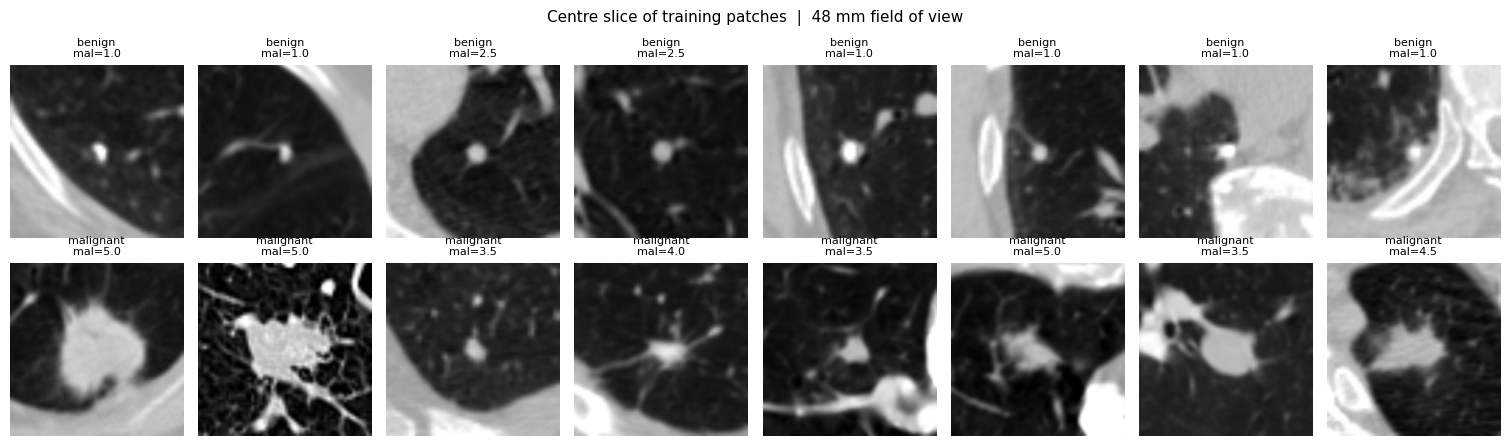

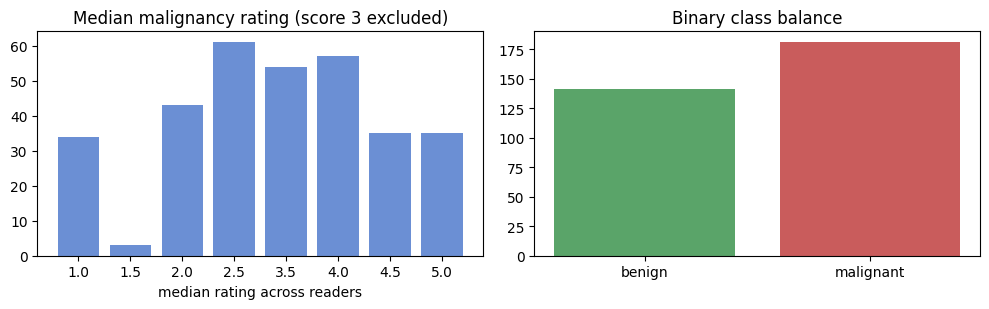

In [14]:
# Visual sanity check, using fold 0's training set (any fold would do).
# Visual sanity check. LOOK AT THIS before trusting any metric: the nodule must sit in the middle
# of every patch. If it does not, the centroid/spacing handling in 4.1.3 is wrong and every number
# downstream is noise.
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(1.9 * n_show, 4.6))
for row, cls in enumerate([0, 1]):
    pool = FOLDS[0]["train"][LABELS[FOLDS[0]["train"]] == cls][:n_show]
    for c in range(n_show):
        ax = axes[row, c]; ax.axis("off")
        if c >= len(pool):
            continue
        j = pool[c]
        ax.imshow(PATCHES[j][PATCHES[j].shape[0] // 2], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{CLASS_NAMES[cls]}\nmal={MALIGNANCY[j]:.1f}", fontsize=8)
fig.suptitle(f"Centre slice of training patches  |  {CFG['PATCH_MM']:.0f} mm field of view"
             + ("   [SMOKE / PHANTOM DATA]" if IS_SMOKE else ""), fontsize=11)
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/data_samples.png", dpi=110); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
vals, cnts = np.unique(MALIGNANCY, return_counts=True)
ax[0].bar([f"{v:.1f}" for v in vals], cnts, color="#6b8fd4")
ax[0].set_title("Median malignancy rating"
                + (" (score 3 excluded)" if CFG["DROP_SCORE_3"] else ""))
ax[0].set_xlabel("median rating across readers")
ax[1].bar(CLASS_NAMES, [int((LABELS == 0).sum()), int((LABELS == 1).sum())],
          color=["#5aa469", "#c95c5c"])
ax[1].set_title("Binary class balance")
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/label_distribution.png", dpi=110); plt.show()

## 4.2 &nbsp;Models

One factory, two architectures, one shared contract. Both return raw logits of shape `(B, 2)` and
both expose their dropout modules to `enable_mc_dropout()` in Task 6, so nothing downstream needs
to know which architecture it is holding.

### Why dropout is injected at *training* time, in Task 4

MC Dropout is not a post-hoc wrapper. It approximates a Bayesian posterior only if dropout was
**active during training**, so the network learned to be robust to its own units being masked. Adding
dropout to an already-trained deterministic network and sampling from it produces noise, not
calibrated uncertainty. So `DROPOUT_P` is set now, in the Task 4 baseline, even though the
uncertainty machinery is not used until Task 6 - the alternative is retraining everything next week.

`DROPOUT_MODE`:
- `head` - dropout only before the classifier. Cheap, but the uncertainty is shallow: only the last
  layer varies, so predictive variance is systematically under-dispersed.
- `head_and_stages` - additional 2D dropout after each residual stage. This is the configuration
  the UQ literature actually validates, and the default here.

In [15]:
import torchvision

class MCDropout2d(nn.Dropout2d):
    """Marker subclass, so the layers WE inserted can be counted and reported separately from
    whatever dropout a third-party backbone brings with it. Task 6 samples over all of them;
    the distinction is for diagnostics, not for gating."""
    pass

class MCDropout(nn.Dropout):
    pass


class ResNet18Nodule(nn.Module):
    """TASK 4 baseline: ImageNet-pretrained ResNet-18 with MC-Dropout capability."""

    def __init__(self, n_classes=2, pretrained=True, p=0.3, mode="head_and_stages"):
        super().__init__()
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        net = torchvision.models.resnet18(weights=weights)
        self.n_features = net.fc.in_features                     # 512

        self.stem = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool)
        self.layer1, self.layer2 = net.layer1, net.layer2
        self.layer3, self.layer4 = net.layer3, net.layer4
        self.pool = nn.AdaptiveAvgPool2d(1)

        use_stage_drop = (mode == "head_and_stages")
        # Rising rate with depth: early features are generic and shared, late features are
        # task-specific and are where epistemic uncertainty actually lives.
        self.d1 = MCDropout2d(p * 0.25) if use_stage_drop else nn.Identity()
        self.d2 = MCDropout2d(p * 0.50) if use_stage_drop else nn.Identity()
        self.d3 = MCDropout2d(p * 0.75) if use_stage_drop else nn.Identity()
        self.d4 = MCDropout2d(p)        if use_stage_drop else nn.Identity()
        self.head_drop = MCDropout(p)
        self.fc = nn.Linear(self.n_features, n_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.d1(self.layer1(x))
        x = self.d2(self.layer2(x))
        x = self.d3(self.layer3(x))
        x = self.d4(self.layer4(x))
        return x

    def forward(self, x):
        f = self.pool(self.forward_features(x)).flatten(1)
        return self.fc(self.head_drop(f))


class ViTNodule(nn.Module):
    """TASK 5 comparison: ImageNet-pretrained ViT / DeiT via timm.

    CAREFUL - drop_rate is not enough. In timm 1.x, drop_rate wires ONLY the classifier-head
    dropout; every dropout inside the transformer blocks stays at p=0.0. Passing drop_rate alone
    therefore builds a model with ~50 dropout modules that are all inert, and Task 6 would then
    sample over the final linear layer alone, producing a confident-looking uncertainty estimate
    with almost no variance in it. proj_drop_rate is the argument that actually reaches
    attn.proj_drop and mlp.drop1/drop2 in every block. Verified on timm 1.0.24: 37 active
    dropout layers with it, 1 without.

    attn_drop stays at 0 deliberately: dropping attention weights perturbs the attention
    distribution itself, which is not the perturbation MC Dropout theory assumes.
    """

    def __init__(self, n_classes=2, pretrained=True, p=0.3,
                 backbone="vit_small_patch16_224", img_size=224):
        super().__init__()
        self.backbone_name = backbone
        kwargs = dict(pretrained=pretrained, num_classes=0,   # num_classes=0 -> pooled features
                      drop_rate=p * 0.5, attn_drop_rate=0.0, img_size=img_size)
        try:
            self.body = timm.create_model(backbone, proj_drop_rate=p * 0.5, **kwargs)
        except TypeError:
            # older timm without proj_drop_rate - set the block dropout rates by hand
            self.body = timm.create_model(backbone, **kwargs)
            for mod_name, mod in self.body.named_modules():
                if isinstance(mod, nn.Dropout) and ("mlp.drop" in mod_name
                                                    or "proj_drop" in mod_name):
                    mod.p = p * 0.5

        self.n_features = self.body.num_features
        self.head_drop = MCDropout(p)
        self.fc = nn.Linear(self.n_features, n_classes)

    def forward_features(self, x):
        return self.body(x)

    def forward(self, x):
        return self.fc(self.head_drop(self.body(x)))


MODEL_REGISTRY = {
    # TASK 4
    "resnet18":   lambda cfg: ResNet18Nodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                             cfg["DROPOUT_MODE"]),
    # TASK 5 - vit_tiny is the specified arm; the others are here for a sensitivity check only
    "vit_tiny":   lambda cfg: ViTNodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                        "vit_tiny_patch16_224", cfg["IMG_SIZE"]),
    "vit_small":  lambda cfg: ViTNodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                        "vit_small_patch16_224", cfg["IMG_SIZE"]),
    "deit_tiny":  lambda cfg: ViTNodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                        "deit_tiny_patch16_224", cfg["IMG_SIZE"]),
}

def build_model(name, cfg):
    if name not in MODEL_REGISTRY:
        raise KeyError(f"Unknown model '{name}'. Available: {list(MODEL_REGISTRY)}")
    return MODEL_REGISTRY[name](cfg).to(DEVICE)


def count_active_dropout(model):
    """Dropout modules with p > 0. A module with p == 0 is inert - it injects no noise - so
    counting every Dropout instance would hide exactly the timm bug described above."""
    return sum(1 for m in model.modules()
               if isinstance(m, (nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d,
                                 nn.AlphaDropout)) and m.p > 0)


for name in MODEL_REGISTRY:
    try:
        m = MODEL_REGISTRY[name](dict(CFG, PRETRAINED=False))
        n_par   = sum(q.numel() for q in m.parameters()) / 1e6
        n_act   = count_active_dropout(m)
        n_inert = sum(1 for mod in m.modules() if isinstance(mod, nn.Dropout) and mod.p == 0)
        with torch.no_grad():
            out = m(torch.zeros(2, 3, CFG["IMG_SIZE"], CFG["IMG_SIZE"]))
        flag = "" if n_act >= 3 else "   <-- TOO FEW for meaningful MC Dropout, see Task 6"
        print(f"{name:12s} {n_par:6.1f}M params | {n_act:3d} ACTIVE dropout "
              f"({n_inert} inert) | out {tuple(out.shape)}{flag}")
        del m
    except Exception as e:
        print(f"{name:12s} FAILED: {type(e).__name__}: {e}")

resnet18       11.2M params |   5 ACTIVE dropout (0 inert) | out (2, 2)
vit_tiny        5.5M params |  38 ACTIVE dropout (13 inert) | out (2, 2)
vit_small      21.7M params |  38 ACTIVE dropout (13 inert) | out (2, 2)
deit_tiny       5.5M params |  38 ACTIVE dropout (13 inert) | out (2, 2)


## 4.3 &nbsp;Evaluation harness

Everything in this section is architecture-agnostic and gets reused by Tasks 4, 5 and 6 unchanged.
It implements the specific metrics the revised proposal (Section 6, "Statistical Evaluation" and
"False-Negative Evaluation") commits to:

| Metric | Why the proposal needs it |
|---|---|
| Accuracy / precision / recall / F1 / AUROC / AUPRC | baseline comparison table |
| **Sensitivity at fixed specificity** 0.90 / 0.95 / 0.99 | the false-negative requirement; a single accuracy number hides FNs |
| **Bootstrap 95% CIs**, resampled **by patient** | an interval, not a point estimate; resampling nodules would give falsely narrow CIs |
| **ECE + Brier** | calibration - required before any confidence threshold means anything |
| **DeLong test** | AUROC comparison ResNet vs ViT with a p-value |
| **McNemar test** | paired error comparison at the operating point |

The bootstrap resamples **patients, not nodules**. This matters: nodules from one patient are
correlated, so nodule-level resampling understates the variance and produces CIs that are too
narrow to be honest.

In [16]:
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, brier_score_loss)
from scipy import stats


def expected_calibration_error(y_true, p_pos, n_bins=15):
    """Equal-width binning ECE. Reported alongside Brier because Brier conflates calibration
    with discrimination, while ECE isolates the calibration part."""
    conf = np.where(p_pos >= 0.5, p_pos, 1.0 - p_pos)      # confidence in the predicted class
    correct = ((p_pos >= 0.5).astype(int) == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece, per_bin = 0.0, []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if not m.any():
            per_bin.append((0.5 * (lo + hi), np.nan, np.nan, 0)); continue
        acc, avg_conf = correct[m].mean(), conf[m].mean()
        ece += (m.sum() / len(conf)) * abs(acc - avg_conf)
        per_bin.append((0.5 * (lo + hi), acc, avg_conf, int(m.sum())))
    return float(ece), per_bin


def sensitivity_at_specificity(y_true, p_pos, target_spec):
    """Highest achievable sensitivity subject to specificity >= target, plus the threshold.
    This is the clinical operating point: in screening you fix the false-positive burden you
    can tolerate and then ask how many cancers you catch."""
    fpr, tpr, thr = roc_curve(y_true, p_pos)
    spec = 1.0 - fpr
    ok = spec >= target_spec
    if not ok.any():
        return np.nan, np.nan, np.nan
    i = int(np.argmax(np.where(ok, tpr, -np.inf)))
    return float(tpr[i]), float(spec[i]), float(thr[i])


def core_metrics(y_true, p_pos, threshold=0.5, cfg=CFG):
    y_pred = (p_pos >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    ece, _ = expected_calibration_error(y_true, p_pos, cfg["N_ECE_BINS"])

    out = dict(
        threshold   = float(threshold),
        n           = int(len(y_true)),
        accuracy    = float(accuracy_score(y_true, y_pred)),
        precision   = float(precision_score(y_true, y_pred, zero_division=0)),
        recall      = float(recall_score(y_true, y_pred, zero_division=0)),
        specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan,
        f1          = float(f1_score(y_true, y_pred, zero_division=0)),
        auroc       = float(roc_auc_score(y_true, p_pos)) if len(np.unique(y_true)) > 1 else np.nan,
        auprc       = float(average_precision_score(y_true, p_pos)),
        brier       = float(brier_score_loss(y_true, p_pos)),
        ece         = float(ece),
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        false_negative_rate = float(fn / (fn + tp)) if (fn + tp) else np.nan,
    )
    for ts in cfg["TARGET_SPECIFICITIES"]:
        sens, spec, thr = sensitivity_at_specificity(y_true, p_pos, ts)
        out[f"sens_at_spec_{int(ts*100)}"] = sens
        out[f"thr_at_spec_{int(ts*100)}"]  = thr
    return out


def bootstrap_ci(y_true, p_pos, groups, metric_fn, n_boot=1000, seed=42, alpha=0.05):
    """Patient-level (cluster) bootstrap: resample PATIENTS with replacement, take all of a
    resampled patient's nodules. Nodule-level resampling would ignore within-patient
    correlation and report intervals that are too narrow."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(groups)
    by_group = {g: np.where(groups == g)[0] for g in uniq}
    vals = []
    for _ in range(n_boot):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([by_group[g] for g in pick])
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            vals.append(metric_fn(y_true[idx], p_pos[idx]))
        except Exception:
            continue
    if not vals:
        return np.nan, np.nan, np.nan
    vals = np.asarray(vals, dtype=float)
    return (float(np.mean(vals)),
            float(np.percentile(vals, 100 * alpha / 2)),
            float(np.percentile(vals, 100 * (1 - alpha / 2))))

In [17]:
# ---- DeLong test: is the AUROC difference between two models statistically significant? ----
# Fast implementation of Sun & Xu (2014), the standard for correlated ROC curves (same test set,
# two models -> the two AUCs are correlated, so an unpaired test would be wrong).

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted, n_pos):
    """preds_sorted: (k_models, n_samples) with all positives first."""
    m, k = n_pos, preds_sorted.shape[0]
    n = preds_sorted.shape[1] - m
    pos, neg = preds_sorted[:, :m], preds_sorted[:, m:]

    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m + n])
    for r in range(k):
        tx[r] = _compute_midrank(pos[r])
        ty[r] = _compute_midrank(neg[r])
        tz[r] = _compute_midrank(preds_sorted[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10))
    return aucs, sx / m + sy / n


def delong_roc_test(y_true, p_a, p_b):
    """Two-sided DeLong test. Returns (auc_a, auc_b, z, p_value)."""
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true, kind="mergesort")      # positives first, ties stable
    n_pos = int(y_true.sum())
    preds = np.vstack([np.asarray(p_a, float), np.asarray(p_b, float)])[:, order]

    aucs, cov = _fast_delong(preds, n_pos)
    l = np.array([[1.0, -1.0]])
    var = float(l @ cov @ l.T)
    if var <= 0:
        return float(aucs[0]), float(aucs[1]), np.nan, np.nan
    z = float((aucs[0] - aucs[1]) / np.sqrt(var))
    # norm.sf, not 1 - norm.cdf: the latter underflows to exactly 0.0 for |z| > ~8 and would
    # print "p = 0", which is not a reportable p-value.
    return float(aucs[0]), float(aucs[1]), z, float(2.0 * stats.norm.sf(abs(z)))


def mcnemar_test(y_true, pred_a, pred_b):
    """Exact McNemar on the discordant pairs: do the two models make DIFFERENT mistakes on the
    same cases? Complements DeLong, which compares ranking rather than decisions."""
    a_ok = (np.asarray(pred_a) == y_true)
    b_ok = (np.asarray(pred_b) == y_true)
    n01 = int((~a_ok & b_ok).sum())      # A wrong, B right
    n10 = int((a_ok & ~b_ok).sum())      # A right, B wrong
    if n01 + n10 == 0:
        return n01, n10, 1.0
    p = float(stats.binomtest(min(n01, n10), n01 + n10, 0.5, alternative="two-sided").pvalue)
    return n01, n10, p


# Self-check on synthetic data: a clearly better scorer must come out with a small p-value.
_rng = np.random.default_rng(0)
_y = np.r_[np.ones(120), np.zeros(120)].astype(int)
_good = np.r_[_rng.normal(1.6, 1, 120), _rng.normal(0, 1, 120)]
_weak = np.r_[_rng.normal(0.4, 1, 120), _rng.normal(0, 1, 120)]
_a, _b, _z, _p = delong_roc_test(_y, _good, _weak)
print(f"DeLong self-check: auc_good={_a:.3f} auc_weak={_b:.3f} z={_z:.2f} p={_p:.2e}")
assert _p < 0.01 and _a > _b, "DeLong implementation is broken"
# A large |z| must still give a representable p. 1 - norm.cdf(|z|) hits exactly 0.0 around
# |z| = 8.3, so a strong result would print "p = 0" - not a reportable number.
_p_extreme = float(2.0 * stats.norm.sf(12.0))
assert _p_extreme > 0.0, "p-value underflowed - delong_roc_test must use norm.sf, not 1-norm.cdf"
print(f"  p at z=12 stays representable: {_p_extreme:.3e}  "
      f"(1-norm.cdf would give {2.0*(1.0-stats.norm.cdf(12.0)):.1f})")
print("McNemar self-check:", mcnemar_test(_y, (_good > 0.8).astype(int), (_weak > 0.2).astype(int)))

DeLong self-check: auc_good=0.896 auc_weak=0.591 z=7.52 p=5.56e-14
  p at z=12 stays representable: 3.553e-33  (1-norm.cdf would give 0.0)
McNemar self-check: (23, 86, 9.593063014050702e-10)


## 4.4 &nbsp;Training loop

One fold's worth of training. Called `N_FOLDS` times by Section 4.5.

Model selection is on **validation AUROC**, not validation accuracy. With class imbalance and a
threshold that gets re-tuned for the clinical operating point anyway, accuracy at 0.5 is the wrong
quantity to select on. Validation here is always a patient-disjoint slice of the *training* pool, so
the fold's test set stays untouched until the model is final.

Both notebooks use this identical loop, optimiser, schedule, early-stopping rule and seed. The only
difference between Task 4 and Task 5 is `CFG["MODEL"]`. Any other difference and a reviewer can
argue the comparison measures tuning effort rather than architecture.

In [18]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

@torch.no_grad()
def predict_deterministic(model, loader):
    """Standard single-pass inference. Dropout OFF - this is the Task 4/5 baseline prediction."""
    model.eval()
    P, Y, J = [], [], []
    for x, y, j in loader:
        logits = model(x.to(DEVICE, non_blocking=True))
        P.append(torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
        Y.append(y.numpy()); J.append(np.asarray(j))
    return np.concatenate(P), np.concatenate(Y), np.concatenate(J)


def train_one_fold(name, cfg, fold, train_loader, val_loader, verbose=True):
    """Train on one fold. Returns (model, history, checkpoint_path)."""
    set_seed(cfg["SEED"] + fold["fold"])
    model = build_model(name, cfg)

    if cfg["CLASS_WEIGHTS"]:
        cnt = np.bincount(LABELS[fold["train"]], minlength=2).astype(np.float32)
        # The sampler already balances the stream; this mild residual weight guards the case
        # where CLASS_WEIGHTS sampling is turned off.
        w = torch.tensor(cnt.sum() / (2.0 * np.maximum(cnt, 1)), dtype=torch.float32, device=DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)
    else:
        criterion = nn.CrossEntropyLoss()

    opt = AdamW(model.parameters(), lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
    sched = CosineAnnealingLR(opt, T_max=cfg["EPOCHS"])
    use_amp = cfg["AMP"] and DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    ckpt = f"{cfg['OUT_DIR']}/{name}_fold{fold['fold']}_best.pt"
    best_auc, best_epoch, bad, history = -np.inf, -1, 0, []
    t0 = time.time()

    for epoch in range(1, cfg["EPOCHS"] + 1):
        model.train()
        tot, seen = 0.0, 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            tot += loss.item() * x.size(0); seen += x.size(0)
        sched.step()

        p_val, y_val, _ = predict_deterministic(model, val_loader)
        val_auc = roc_auc_score(y_val, p_val) if len(np.unique(y_val)) > 1 else np.nan
        val_acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))
        history.append(dict(fold=fold["fold"], epoch=epoch, train_loss=tot / max(seen, 1),
                            val_auroc=float(val_auc), val_acc=float(val_acc),
                            lr=opt.param_groups[0]["lr"]))

        improved = np.isfinite(val_auc) and val_auc > best_auc + 1e-5
        if improved:
            best_auc, best_epoch, bad = float(val_auc), epoch, 0
            torch.save(dict(model=model.state_dict(), cfg=cfg, name=name,
                            fold=fold["fold"], epoch=epoch, val_auroc=best_auc,
                            fingerprint=FINGERPRINT), ckpt)
        else:
            bad += 1

        if verbose:
            print(f"    epoch {epoch:3d}/{cfg['EPOCHS']} | loss {history[-1]['train_loss']:.4f} "
                  f"| val AUROC {val_auc:.4f} | val acc {val_acc:.4f}"
                  f"{'  <- best' if improved else ''}")
        if bad >= cfg["PATIENCE"]:
            print(f"    early stop at epoch {epoch} (no val AUROC gain for {bad} epochs)")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model"])
    print(f"    restored best epoch {best_epoch} (val AUROC {best_auc:.4f}) "
          f"| {(time.time()-t0)/60:.1f} min")
    return model, pd.DataFrame(history), ckpt

In [19]:
def evaluate_and_report(name, p_test, y_test, j_test, cfg=CFG, tag="deterministic"):
    """Full metric block + bootstrap CIs + saved artefacts. Used by Tasks 4, 5 and 6."""
    groups = PATIENT_ID[j_test]
    m = core_metrics(y_test, p_test, 0.5, cfg)
    m.update(model=name, tag=tag, smoke=IS_SMOKE,
             n_test_patients=int(len(np.unique(groups))))

    for key, fn in [("auroc", lambda a, b: roc_auc_score(a, b)),
                    ("auprc", lambda a, b: average_precision_score(a, b)),
                    ("accuracy", lambda a, b: accuracy_score(a, (b >= 0.5).astype(int))),
                    ("recall", lambda a, b: recall_score(a, (b >= 0.5).astype(int),
                                                         zero_division=0)),
                    ("f1", lambda a, b: f1_score(a, (b >= 0.5).astype(int), zero_division=0))]:
        mean, lo, hi = bootstrap_ci(y_test, p_test, groups, fn,
                                    cfg["N_BOOTSTRAP"], cfg["SEED"])
        m[f"{key}_ci_low"], m[f"{key}_ci_high"] = lo, hi

    banner = f"  {name} / {tag}  " + ("[SMOKE - NOT REPORTABLE]" if IS_SMOKE else "")
    print("=" * 78); print(banner); print("=" * 78)
    print(f"  test set: {m['n']} nodules from {m['n_test_patients']} patients")
    print(f"  AUROC        {m['auroc']:.4f}  [{m['auroc_ci_low']:.4f}, {m['auroc_ci_high']:.4f}]")
    print(f"  AUPRC        {m['auprc']:.4f}  [{m['auprc_ci_low']:.4f}, {m['auprc_ci_high']:.4f}]")
    print(f"  Accuracy     {m['accuracy']:.4f}  [{m['accuracy_ci_low']:.4f}, "
          f"{m['accuracy_ci_high']:.4f}]")
    print(f"  Sensitivity  {m['recall']:.4f}  [{m['recall_ci_low']:.4f}, {m['recall_ci_high']:.4f}]")
    print(f"  Specificity  {m['specificity']:.4f}")
    print(f"  Precision    {m['precision']:.4f}      F1  {m['f1']:.4f}")
    print(f"  Brier        {m['brier']:.4f}      ECE {m['ece']:.4f}")
    print(f"  Confusion    TP={m['tp']} FP={m['fp']} TN={m['tn']} FN={m['fn']}"
          f"   (FN rate {m['false_negative_rate']:.3f})")
    print("  -- clinical operating points (the false-negative requirement) --")
    for ts in cfg["TARGET_SPECIFICITIES"]:
        s = m[f"sens_at_spec_{int(ts*100)}"]
        t = m[f"thr_at_spec_{int(ts*100)}"]
        print(f"    sensitivity @ specificity>={ts:.2f} : "
              + (f"{s:.4f}  (threshold {t:.4f})" if np.isfinite(s) else "not achievable"))

    np.savez(f"{cfg['OUT_DIR']}/{name}_{tag}_predictions.npz",
             p=p_test, y=y_test, cache_index=j_test, patient_id=groups)
    with open(f"{cfg['OUT_DIR']}/{name}_{tag}_metrics.json", "w") as f:
        json.dump(m, f, indent=2, default=float)
    return m


def plot_roc_pr(curves, title):
    """curves: list of (label, y_true, p_pos)."""
    from sklearn.metrics import precision_recall_curve
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    for label, y, p in curves:
        fpr, tpr, _ = roc_curve(y, p)
        ax[0].plot(fpr, tpr, lw=1.8, label=f"{label} (AUC {roc_auc_score(y, p):.3f})")
        pr, rc, _ = precision_recall_curve(y, p)
        ax[1].plot(rc, pr, lw=1.8, label=f"{label} (AP {average_precision_score(y, p):.3f})")
    ax[0].plot([0, 1], [0, 1], "k:", lw=1)
    for ts in CFG["TARGET_SPECIFICITIES"]:
        ax[0].axvline(1 - ts, color="grey", ls="--", lw=0.7)
        ax[0].text(1 - ts, 0.02, f"spec {ts:.2f}", rotation=90, fontsize=7, color="grey")
    ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity")
    ax[0].set_title("ROC"); ax[0].legend(loc="lower right", fontsize=8)
    ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
    ax[1].set_title("Precision-Recall"); ax[1].legend(loc="lower left", fontsize=8)
    fig.suptitle(title + ("   [SMOKE]" if IS_SMOKE else ""))
    plt.tight_layout()
    plt.savefig(f"{CFG['OUT_DIR']}/{title.replace(' ','_').replace('/','-')}_roc_pr.png", dpi=110)
    plt.show()


RESULTS = []   # accumulates every metric dict produced in this notebook

---

## 4.5 &nbsp;Cross-validation run

Trains `N_FOLDS` models. Each one predicts on its own held-out fold, and those predictions are
written into a single **out-of-fold (OOF)** vector covering every nodule in the dataset - each
scored exactly once, by a model that never saw its patient.

Two levels of result come out, and they answer different questions:

- **Per-fold metrics**, reported as mean &plusmn; SD across the 5 folds. The SD is the honest
  measure of how stable the result is. A 0.88 &plusmn; 0.02 and a 0.88 &plusmn; 0.11 are very
  different findings, and only the first is worth building on.
- **Pooled OOF metrics**, computed once over all nodules, with 95% CIs from a patient-level
  bootstrap. This is the headline number, and the OOF prediction vector is what makes a paired
  comparison against the other architecture possible later.

GPU memory is released between folds - five transformer models will not fit on one card at once.

In [20]:
def run_cross_validation(name, cfg, folds):
    """Train every fold, accumulate out-of-fold predictions, report per-fold and pooled metrics."""
    print("#" * 78)
    print(f"#  {cfg['N_FOLDS']}-FOLD PATIENT-LEVEL CV : {name}"
          + ("   [SMOKE DATA]" if IS_SMOKE else ""))
    print(f"#  fingerprint {FINGERPRINT}")
    print("#" * 78)

    oof_p = np.full(len(LABELS), np.nan, dtype=np.float64)
    per_fold, histories, ckpts = [], [], []
    t_start = time.time()

    for f in folds:
        print(f"\n--- fold {f['fold'] + 1}/{len(folds)} "
              f"({len(f['train'])} train / {len(f['val'])} val / {len(f['test'])} test nodules) ---")
        tl, vl, sl = make_fold_loaders(f, cfg)
        model, hist, ckpt = train_one_fold(name, cfg, f, tl, vl)

        p, y, j = predict_deterministic(model, sl)
        oof_p[j] = p                                  # each index written exactly once
        m = core_metrics(y, p, 0.5, cfg)
        m.update(fold=f["fold"], n_test_patients=int(len(np.unique(PATIENT_ID[j]))))
        per_fold.append(m)
        histories.append(hist); ckpts.append(ckpt)
        print(f"    fold {f['fold']} test AUROC {m['auroc']:.4f} | acc {m['accuracy']:.4f} "
              f"| sens {m['recall']:.4f} | FN {m['fn']}")

        del model, tl, vl, sl                          # 5 models will not co-reside on one GPU
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    assert not np.isnan(oof_p).any(), "some nodules never received an out-of-fold prediction"
    print(f"\nAll folds complete in {(time.time()-t_start)/60:.1f} min")
    return oof_p, pd.DataFrame(per_fold), pd.concat(histories, ignore_index=True), ckpts


OOF_P, FOLD_METRICS, HISTORY, CKPTS = run_cross_validation(CFG["MODEL"], CFG, FOLDS)

##############################################################################
#  5-FOLD PATIENT-LEVEL CV : resnet18
#  fingerprint 1675f74dcca2d3ce
##############################################################################

--- fold 1/5 (221 train / 38 val / 63 test nodules) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


    epoch   1/30 | loss 0.8646 | val AUROC 0.7415 | val acc 0.6579  <- best
    epoch   2/30 | loss 0.9017 | val AUROC 0.6960 | val acc 0.4211
    epoch   3/30 | loss 0.7657 | val AUROC 0.7330 | val acc 0.4474
    epoch   4/30 | loss 0.6516 | val AUROC 0.8182 | val acc 0.5789  <- best
    epoch   5/30 | loss 0.6049 | val AUROC 0.8040 | val acc 0.4474
    epoch   6/30 | loss 0.4997 | val AUROC 0.8580 | val acc 0.4737  <- best
    epoch   7/30 | loss 0.6021 | val AUROC 0.8835 | val acc 0.6579  <- best
    epoch   8/30 | loss 0.5851 | val AUROC 0.8466 | val acc 0.7895
    epoch   9/30 | loss 0.4105 | val AUROC 0.8665 | val acc 0.8158
    epoch  10/30 | loss 0.3753 | val AUROC 0.8892 | val acc 0.8158  <- best
    epoch  11/30 | loss 0.4048 | val AUROC 0.8977 | val acc 0.8421  <- best
    epoch  12/30 | loss 0.2830 | val AUROC 0.8920 | val acc 0.8158
    epoch  13/30 | loss 0.2968 | val AUROC 0.8920 | val acc 0.7895
    epoch  14/30 | loss 0.3424 | val AUROC 0.9062 | val acc 0.8684  <- best

## 4.6 &nbsp;Results

Per-fold spread first, then the pooled out-of-fold numbers with patient-level bootstrap CIs.

The bootstrap resamples **patients, not nodules**. Nodules from one patient are correlated, so
nodule-level resampling understates the variance and produces intervals that are too narrow to be
honest.

### Expect the pooled OOF AUROC to sit below the per-fold mean

This is not a bug and it is worth understanding before you report either number. AUROC depends only
on the *ranking* of scores. Within one fold, one model produced every score, so the ranking is
internally consistent. The pooled OOF vector splices together scores from five **different** models,
and nothing forces them onto a common scale - fold 2's "0.6" may sit at a different risk level from
fold 4's "0.6". Interleaving them blurs the ranking, so pooled AUROC is typically a little lower
than the mean of the per-fold AUROCs. The wider the per-fold SD, the larger the gap.

Which to quote, then:

- **Per-fold mean &plusmn; SD is the headline** for "report accuracy, AUC, sensitivity". It is what
  the 5-fold protocol is for, and the SD is information the pooled number destroys.
- **Pooled OOF is what the paired comparison uses.** Both architectures get pooled exactly the same
  way, so whatever blurring occurs applies to both equally and the *comparison* stays fair even
  though the absolute value is slightly pessimistic.

If the gap is large - more than a couple of points - that is a signal in itself: the folds disagree,
so the result is unstable and needs more patients before it means much.

In [21]:
# ---- per-fold spread ----
show = ["fold", "n", "auroc", "auprc", "accuracy", "recall", "specificity", "precision", "f1",
        "ece", "brier", "tp", "fp", "tn", "fn"]
print(f"PER-FOLD RESULTS  ({CFG['MODEL']})" + ("   [SMOKE - NOT REPORTABLE]" if IS_SMOKE else ""))
print(FOLD_METRICS[show].round(4).to_string(index=False))

agg = FOLD_METRICS[["auroc", "auprc", "accuracy", "recall", "specificity", "f1", "ece"]]
print("\nmean +/- SD across folds")
for c in agg.columns:
    print(f"  {c:12s} {agg[c].mean():.4f} +/- {agg[c].std(ddof=1):.4f}")
FOLD_METRICS.to_csv(f"{CFG['OUT_DIR']}/{CFG['MODEL']}_fold_metrics.csv", index=False)

# ---- pooled out-of-fold ----
POOLED = evaluate_and_report(CFG["MODEL"], OOF_P, LABELS, np.arange(len(LABELS)), CFG,
                             tag="oof_cv")
POOLED.update(n_folds=CFG["N_FOLDS"], fingerprint=FINGERPRINT,
              auroc_fold_mean=float(agg["auroc"].mean()),
              auroc_fold_sd=float(agg["auroc"].std(ddof=1)))
RESULTS.append(POOLED)

PER-FOLD RESULTS  (resnet18)
 fold  n  auroc  auprc  accuracy  recall  specificity  precision     f1    ece  brier  tp  fp  tn  fn
    0 63 0.9446 0.9708    0.8413  0.7750       0.9565     0.9688 0.8611 0.1492 0.1322  31   1  22   9
    1 52 0.8787 0.9086    0.7885  0.8846       0.6923     0.7419 0.8070 0.1883 0.1778  23   8  18   3
    2 69 0.9386 0.9400    0.8261  0.8182       0.8333     0.8182 0.8182 0.1037 0.1100  27   6  30   6
    3 64 0.9251 0.9163    0.8594  0.9655       0.7714     0.7778 0.8615 0.1483 0.1392  28   8  27   1
    4 74 0.9299 0.9754    0.8649  0.8491       0.9048     0.9574 0.9000 0.0882 0.1093  45   2  19   8

mean +/- SD across folds
  auroc        0.9234 +/- 0.0261
  auprc        0.9422 +/- 0.0305
  accuracy     0.8360 +/- 0.0307
  recall       0.8585 +/- 0.0721
  specificity  0.8317 +/- 0.1049
  f1           0.8496 +/- 0.0375
  ece          0.1355 +/- 0.0400
  resnet18 / oof_cv  
  test set: 322 nodules from 187 patients
  AUROC        0.9005  [0.8668, 0.9344

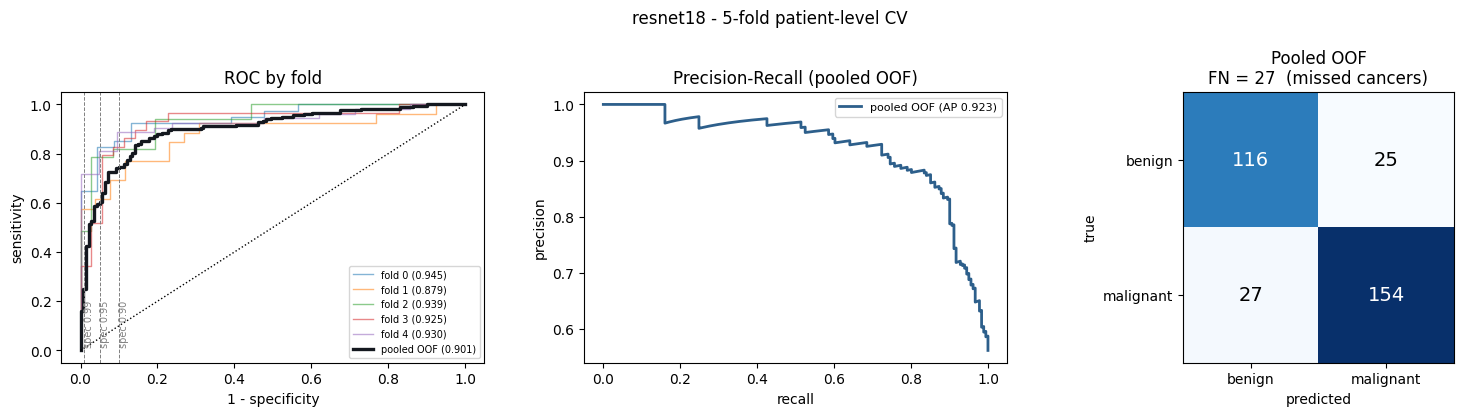

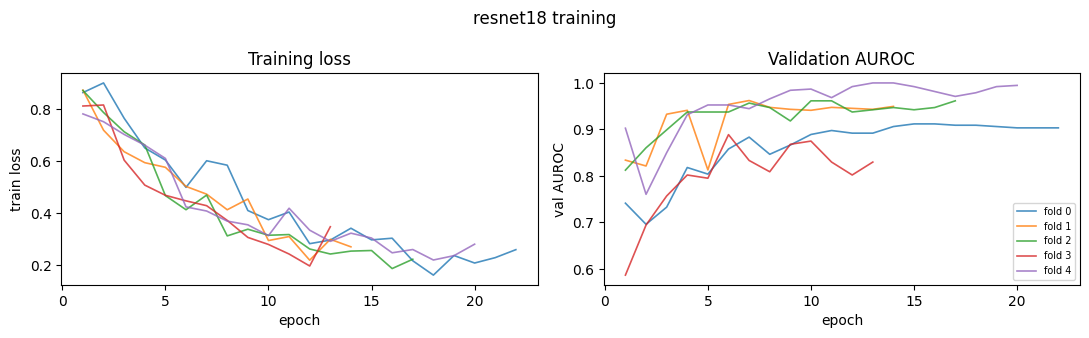

In [22]:
# ---- curves: per-fold ROC plus the pooled OOF curve ----
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.2))

for f in FOLDS:
    j = f["test"]
    fpr, tpr, _ = roc_curve(LABELS[j], OOF_P[j])
    ax[0].plot(fpr, tpr, lw=1.0, alpha=.55,
               label=f"fold {f['fold']} ({roc_auc_score(LABELS[j], OOF_P[j]):.3f})")
fpr, tpr, _ = roc_curve(LABELS, OOF_P)
ax[0].plot(fpr, tpr, lw=2.4, color="#14181f",
           label=f"pooled OOF ({roc_auc_score(LABELS, OOF_P):.3f})")
ax[0].plot([0, 1], [0, 1], "k:", lw=1)
for ts in CFG["TARGET_SPECIFICITIES"]:
    ax[0].axvline(1 - ts, color="grey", ls="--", lw=.7)
    ax[0].text(1 - ts, .02, f"spec {ts:.2f}", rotation=90, fontsize=7, color="grey")
ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity")
ax[0].set_title("ROC by fold"); ax[0].legend(fontsize=7, loc="lower right")

pr, rc, _ = precision_recall_curve(LABELS, OOF_P)
ax[1].plot(rc, pr, lw=2, color="#2d5f8b",
           label=f"pooled OOF (AP {average_precision_score(LABELS, OOF_P):.3f})")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title("Precision-Recall (pooled OOF)"); ax[1].legend(fontsize=8)

cm = confusion_matrix(LABELS, (OOF_P >= 0.5).astype(int), labels=[0, 1])
ax[2].imshow(cm, cmap="Blues")
for i in range(2):
    for k in range(2):
        ax[2].text(k, i, cm[i, k], ha="center", va="center", fontsize=14,
                   color="white" if cm[i, k] > cm.max() / 2 else "black")
ax[2].set_xticks([0, 1], CLASS_NAMES); ax[2].set_yticks([0, 1], CLASS_NAMES)
ax[2].set_xlabel("predicted"); ax[2].set_ylabel("true")
ax[2].set_title(f"Pooled OOF\nFN = {cm[1,0]}  (missed cancers)")

fig.suptitle(f"{CFG['MODEL']} - {CFG['N_FOLDS']}-fold patient-level CV"
             + ("   [SMOKE]" if IS_SMOKE else ""))
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/{CFG['MODEL']}_curves.png", dpi=110); plt.show()

# ---- training curves per fold ----
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, g in HISTORY.groupby("fold"):
    ax[0].plot(g.epoch, g.train_loss, lw=1.2, alpha=.8, label=f"fold {k}")
    ax[1].plot(g.epoch, g.val_auroc, lw=1.2, alpha=.8, label=f"fold {k}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_title("Training loss")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val AUROC"); ax[1].set_title("Validation AUROC")
ax[1].legend(fontsize=7)
fig.suptitle(f"{CFG['MODEL']} training" + ("   [SMOKE]" if IS_SMOKE else ""))
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/{CFG['MODEL']}_training.png", dpi=110); plt.show()

---

## 4.7 &nbsp;Results bundle - the file to hand over

Everything needed to compare this run against the other architecture, in one self-describing
folder. Save the notebook version; Kaggle keeps `/kaggle/working`, and the folder can then be
downloaded or attached as a dataset.

The bundle carries the **fingerprint** and the **per-nodule OOF predictions**, which is what makes a
paired comparison possible. Summary metrics alone are not enough: DeLong and McNemar need each
model's score for each individual nodule, and no amount of AUROC point estimates can reconstruct
that.

Deliberately included, and each one is load-bearing:

| File | Why the comparison needs it |
|---|---|
| `*_oof_predictions.npz` | per-nodule probability, label, patient, fold - the paired-test input |
| `*_fold_metrics.csv` | per-fold spread, for mean &plusmn; SD |
| `*_summary.json` | pooled metrics, full config, fingerprint, environment |
| `fold_table.csv` | the split itself, so the folds can be verified as identical |
| `*_curves.png`, `*_training.png` | figures for the report |

In [23]:
MODEL = CFG["MODEL"]

# ---- per-nodule out-of-fold predictions: the paired-comparison input ----
np.savez_compressed(
    f"{CFG['OUT_DIR']}/{MODEL}_oof_predictions.npz",
    p            = OOF_P,
    y            = LABELS,
    cache_index  = np.arange(len(LABELS)),
    patient_id   = PATIENT_ID.astype(object),
    fold         = FOLD_OF,
    malignancy   = MALIGNANCY,
    model        = MODEL,
    fingerprint  = FINGERPRINT,
)

SUMMARY_JSON = dict(
    model            = MODEL,
    task             = "TASK 04 baseline CNN" if MODEL.startswith("resnet") else
                       "TASK 05 ViT comparison arm",
    fingerprint      = FINGERPRINT,
    smoke            = bool(IS_SMOKE),
    n_nodules        = int(len(LABELS)),
    n_patients       = int(len(np.unique(PATIENT_ID))),
    class_balance    = dict(benign=int((LABELS == 0).sum()), malignant=int((LABELS == 1).sum())),
    n_folds          = int(CFG["N_FOLDS"]),
    protocol         = {k: CFG[k] for k in PROTOCOL_KEYS},
    config           = {k: v for k, v in CFG.items() if k not in ("OUT_DIR",)},
    build_config     = BUILD_CFG,
    pooled_oof       = {k: v for k, v in POOLED.items() if isinstance(v, (int, float, bool, str))},
    per_fold         = FOLD_METRICS.to_dict("records"),
    fold_summary     = {c: dict(mean=float(FOLD_METRICS[c].mean()),
                                sd=float(FOLD_METRICS[c].std(ddof=1)))
                        for c in ["auroc", "auprc", "accuracy", "recall", "specificity",
                                  "f1", "ece", "brier"]},
    checkpoints      = [os.path.basename(c) for c in CKPTS],
    environment      = dict(torch=torch.__version__,
                            gpu=(torch.cuda.get_device_name(0)
                                 if torch.cuda.is_available() else None)),
)
with open(f"{CFG['OUT_DIR']}/{MODEL}_summary.json", "w") as fh:
    json.dump(SUMMARY_JSON, fh, indent=2, default=str)

HISTORY.to_csv(f"{CFG['OUT_DIR']}/{MODEL}_history.csv", index=False)
pd.DataFrame(RESULTS).to_csv(f"{CFG['OUT_DIR']}/{MODEL}_results.csv", index=False)

print(f"BUNDLE -> {CFG['OUT_DIR']}")
for p in sorted(glob.glob(f"{CFG['OUT_DIR']}/*")):
    print(f"  {os.path.getsize(p)/1024:9.1f} KB  {os.path.basename(p)}")

print(f"""
{'='*78}
{MODEL}  |  {CFG['N_FOLDS']}-fold patient-level CV  |  fingerprint {FINGERPRINT}
{'='*78}
  pooled OOF AUROC   {POOLED['auroc']:.4f}  [{POOLED['auroc_ci_low']:.4f}, {POOLED['auroc_ci_high']:.4f}]
  per-fold AUROC     {POOLED['auroc_fold_mean']:.4f} +/- {POOLED['auroc_fold_sd']:.4f}
  accuracy           {POOLED['accuracy']:.4f}
  sensitivity        {POOLED['recall']:.4f}      specificity {POOLED['specificity']:.4f}
  sens @ spec 0.90   {POOLED['sens_at_spec_90']:.4f}
  sens @ spec 0.95   {POOLED['sens_at_spec_95']:.4f}
  false negatives    {POOLED['fn']}

CHECKLIST before reporting
  [{'X' if not IS_SMOKE else ' '}] real LIDC data (SMOKE mode is currently {IS_SMOKE})
  [{'X' if len(LABELS) >= 500 else ' '}] >= 500 nodules  (have {len(LABELS)})
  [{'X' if len(np.unique(PATIENT_ID)) >= 100 else ' '}] >= 100 patients  (have {len(np.unique(PATIENT_ID))})
  [ ] patch visualisation in 4.1.8 inspected - nodules centred

TO HAND OVER
  1. Save Version, then download the folder above (or publish it as a Kaggle Dataset).
  2. Send BOTH files at minimum: {MODEL}_oof_predictions.npz and {MODEL}_summary.json
  3. Quote the fingerprint: {FINGERPRINT}
     The other notebook must print the SAME fingerprint. If it does not, the two runs used
     different data or different folds and cannot be compared with paired statistics.
{'='*78}
""")

BUNDLE -> /kaggle/working/resnet18_task_outputs
      345.5 KB  data_samples.png
        0.2 KB  fold_table.csv
       28.9 KB  label_distribution.png
       77.6 KB  resnet18_curves.png
    43740.9 KB  resnet18_fold0_best.pt
    43740.9 KB  resnet18_fold1_best.pt
    43740.9 KB  resnet18_fold2_best.pt
    43740.9 KB  resnet18_fold3_best.pt
    43740.9 KB  resnet18_fold4_best.pt
        1.7 KB  resnet18_fold_metrics.csv
        7.0 KB  resnet18_history.csv
        1.1 KB  resnet18_oof_cv_metrics.json
       26.1 KB  resnet18_oof_cv_predictions.npz
        4.7 KB  resnet18_oof_predictions.npz
        1.0 KB  resnet18_results.csv
        7.8 KB  resnet18_summary.json
       76.7 KB  resnet18_training.png

resnet18  |  5-fold patient-level CV  |  fingerprint 1675f74dcca2d3ce
  pooled OOF AUROC   0.9005  [0.8668, 0.9344]
  per-fold AUROC     0.9234 +/- 0.0261
  accuracy           0.8385
  sensitivity        0.8508      specificity 0.8227
  sens @ spec 0.90   0.7459
  sens @ spec 0.95   0.6